In [32]:
#all libraries needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris, load_wine, load_digits, load_breast_cancer, make_blobs, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC, SVR, LinearSVR
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch, SpectralClustering, AffinityPropagation
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, adjusted_mutual_info_score, homogeneity_score, completeness_score, v_measure_score
from sklearn.inspection import DecisionBoundaryDisplay
from kneed import KneeLocator


Task(a):data understanding

In [19]:
#data loading
data=pd.read_csv(r'C:\afreennnn\pulsar_stars.csv')
data.head()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [20]:
#dimensions, data types,
print("dimension of dataset",data.shape)
print("information about data:",data.info(()))

print('null value:',data.isnull().sum())


dimension of dataset (17898, 9)
<class 'pandas.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                17898 non-null  float64
 1    Standard deviation of the integrated profile  17898 non-null  float64
 2    Excess kurtosis of the integrated profile     17898 non-null  float64
 3    Skewness of the integrated profile            17898 non-null  float64
 4    Mean of the DM-SNR curve                      17898 non-null  float64
 5    Standard deviation of the DM-SNR curve        17898 non-null  float64
 6    Excess kurtosis of the DM-SNR curve           17898 non-null  float64
 7    Skewness of the DM-SNR curve                  17898 non-null  float64
 8   target_class                                   17898 non-null  int64  
dtypes: float64(8), int64(1)
memory

In [21]:
col_names = data.columns
data.columns = data.columns.str.strip()
print(f"name of the columns:\n",col_names)

name of the columns:
 Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='str')


In [27]:
#changing columns name for convenience
data.columns = ['IP Mean', 'IP Sd', 'IP Kurtosis', 'IP Skewness',
              'DM-SNR Mean', 'DM-SNR Sd', 'DM-SNR Kurtosis', 'DM-SNR Skewness','target_class']
print(f"name of the columns:\n",col_names)

name of the columns:
 Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='str')


In [28]:
print(data['target_class'].value_counts())
print(data['target_class'].value_counts()/np.float64(len(data)))

target_class
0    16259
1     1639
Name: count, dtype: int64
target_class
0    0.908426
1    0.091574
Name: count, dtype: float64


In [29]:
round(data.describe(),2)

,IP Mean,IP Sd,IP Kurtosis,IP Skewness,DM-SNR Mean,DM-SNR Sd,DM-SNR Kurtosis,DM-SNR Skewness,target_class
count,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00,17898.00
mean,111.08,46.55,0.48,1.77,12.61,26.33,8.30,104.86,0.09
std,25.65,6.84,1.06,6.17,29.47,19.47,4.51,106.51,0.29
min,5.81,24.77,-1.88,-1.79,0.21,7.37,-3.14,-1.98,0.00
25%,100.93,42.38,0.03,-0.19,1.92,14.44,5.78,34.96,0.00
50%,115.08,46.95,0.22,0.20,2.80,18.46,8.43,83.06,0.00
75%,127.09,51.02,0.47,0.93,5.46,28.43,10.70,139.31,0.00
max,192.62,98.78,8.07,68.10,223.39,110.64,34.54,1191.00,1.00


Text(0, 0.5, 'Number of pulsar stars')

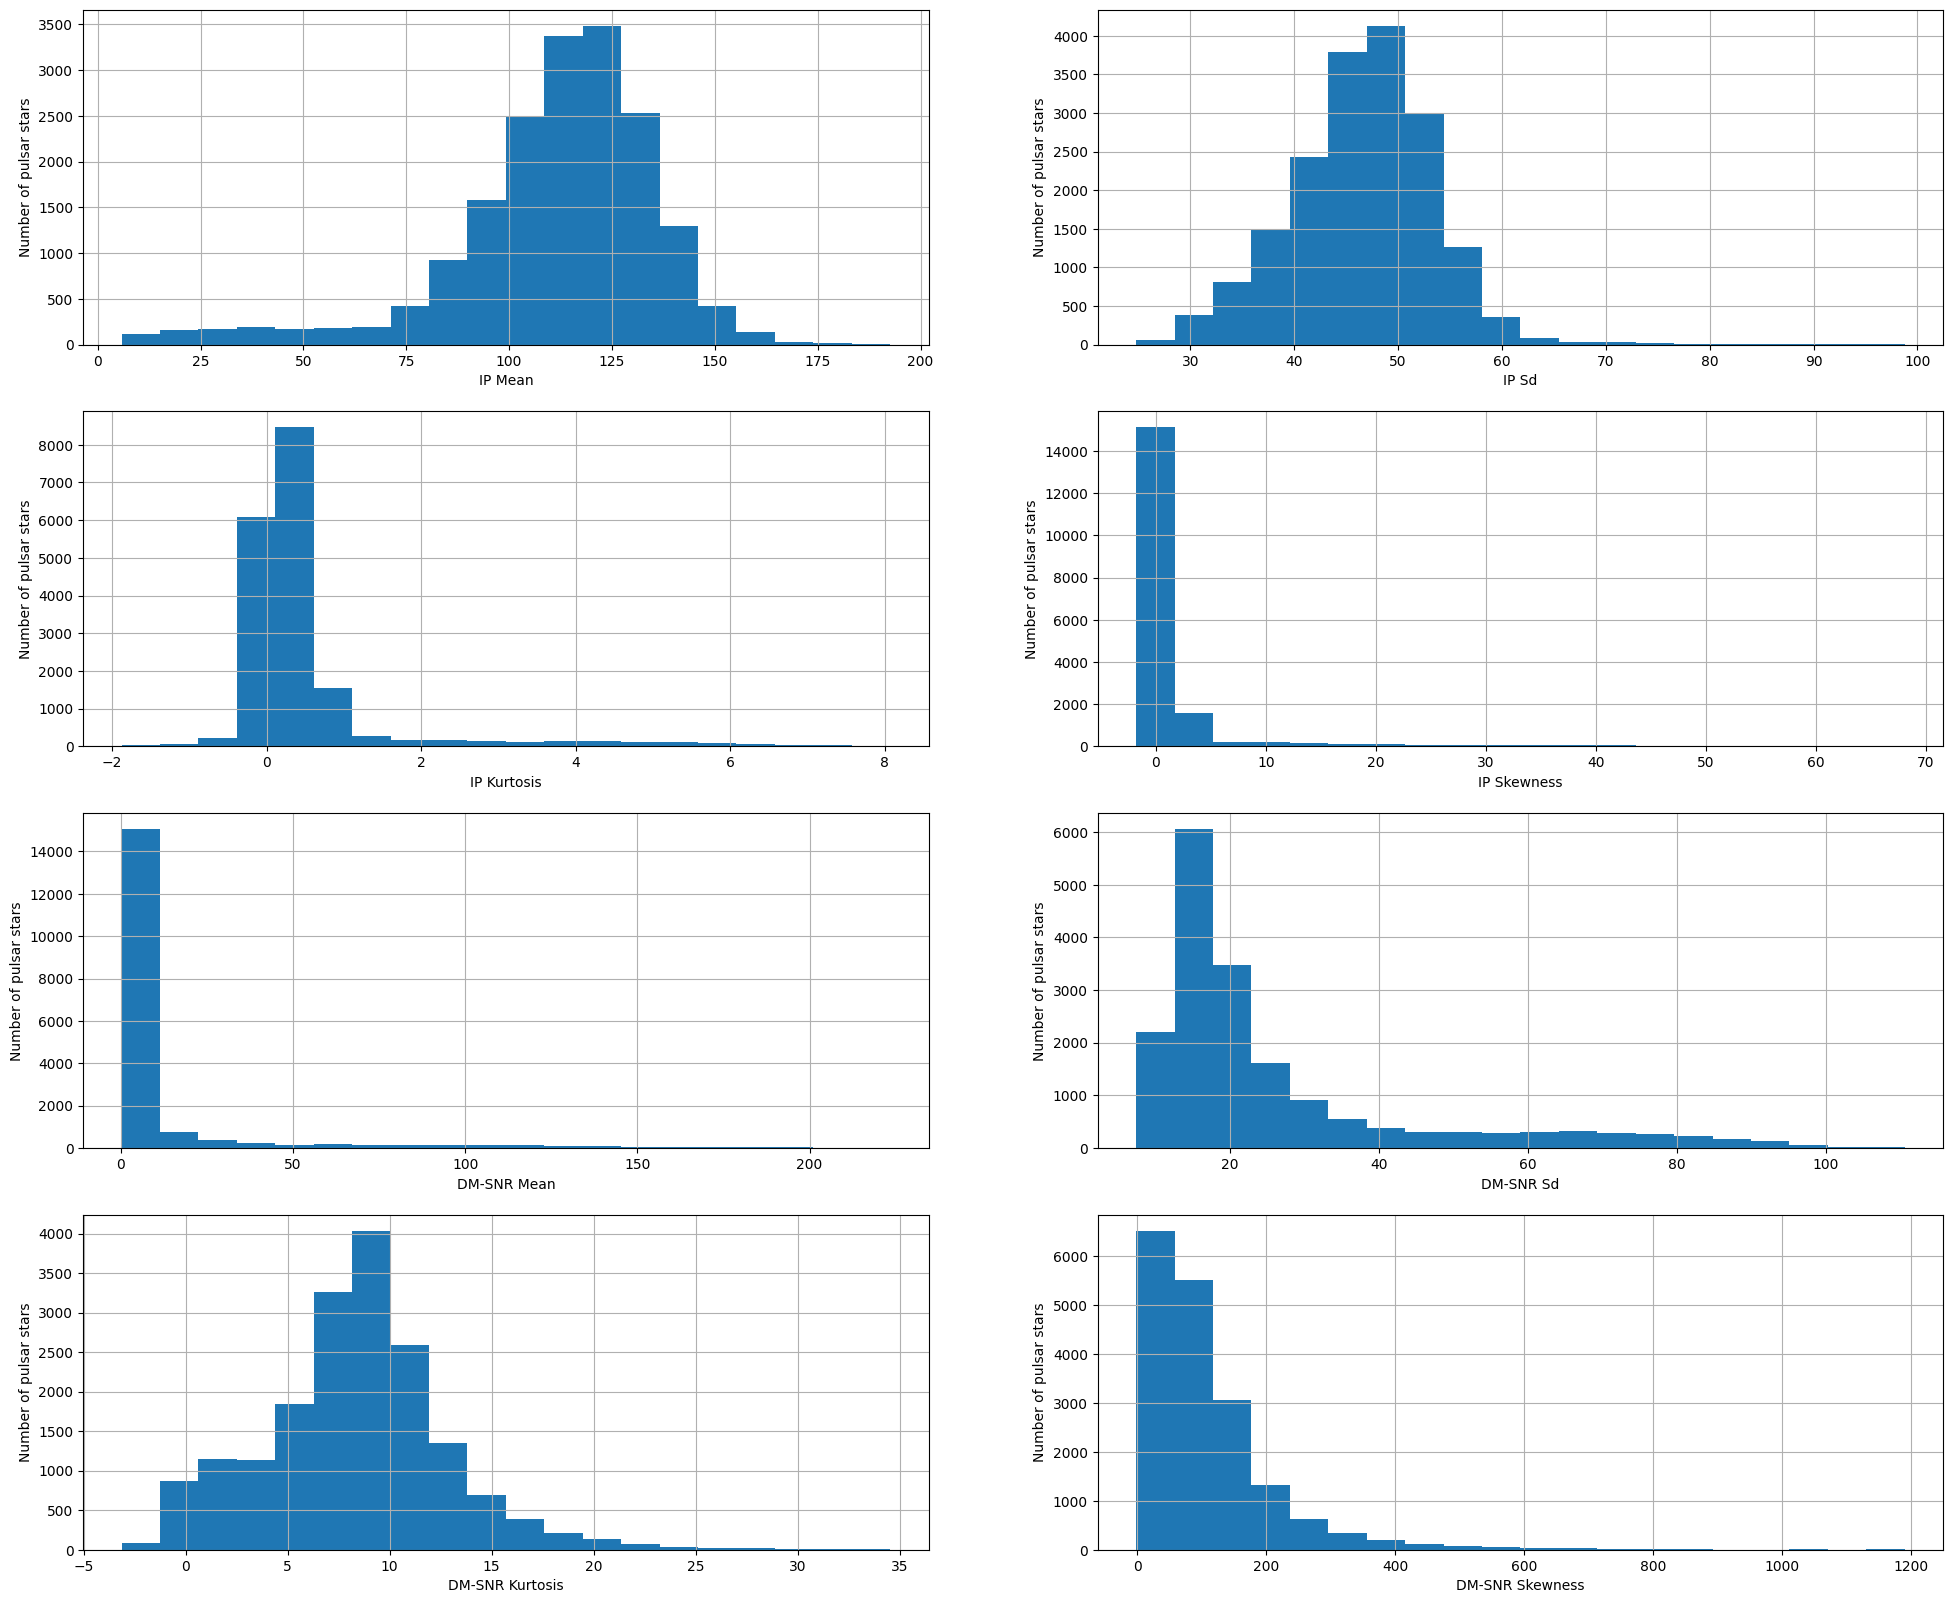

In [30]:
plt.figure(figsize=(24,20))
plt.subplot(4, 2, 1)
fig = data['IP Mean'].hist(bins=20)
fig.set_xlabel('IP Mean')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 2)
fig = data['IP Sd'].hist(bins=20)
fig.set_xlabel('IP Sd')
fig.set_ylabel('Number of pulsar stars')
plt.subplot(4, 2, 3)
fig = data['IP Kurtosis'].hist(bins=20)
fig.set_xlabel('IP Kurtosis')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 4)
fig = data['IP Skewness'].hist(bins=20)
fig.set_xlabel('IP Skewness')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 5)
fig = data['DM-SNR Mean'].hist(bins=20)
fig.set_xlabel('DM-SNR Mean')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 6)
fig = data['DM-SNR Sd'].hist(bins=20)
fig.set_xlabel('DM-SNR Sd')
fig.set_ylabel('Number of pulsar stars')

plt.subplot(4, 2, 7)
fig = data['DM-SNR Kurtosis'].hist(bins=20)
fig.set_xlabel('DM-SNR Kurtosis')
fig.set_ylabel('Number of pulsar stars')
plt.subplot(4, 2, 8)
fig = data['DM-SNR Skewness'].hist(bins=20)
fig.set_xlabel('DM-SNR Skewness')
fig.set_ylabel('Number of pulsar stars')

task(b): svm

In [33]:
data = data.dropna()

training_set, test_set = train_test_split(
    data,
    test_size=0.2,
    random_state=1,
    stratify=data["target_class"]
)

X_train = training_set.drop(columns=["target_class"]).values
Y_train = training_set["target_class"].values

X_test = test_set.drop(columns=["target_class"]).values
Y_test = test_set["target_class"].values


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pca=PCA(n_components=2)
X_train=pca.fit_transform(X_train)
X_test=pca.transform(X_test)


classifier = SVC(
    kernel="rbf",
    C=1,
    gamma='scale',
    random_state=1
)

classifier.fit(X_train, Y_train)

Y_pred = classifier.predict(X_test)

test_set["Predictions"] = Y_pred


cm = confusion_matrix(Y_test, Y_pred)

accuracy = float(cm.diagonal().sum()) / len(Y_test)

print("\nAccuracy Of SVM For The Given Dataset : ", accuracy)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))


Accuracy Of SVM For The Given Dataset :  0.9754189944134078

Confusion Matrix:
[[3239   13]
 [  75  253]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3252
           1       0.95      0.77      0.85       328

    accuracy                           0.98      3580
   macro avg       0.96      0.88      0.92      3580
weighted avg       0.97      0.98      0.97      3580



In [36]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
   
)

print(cm)
TN, FP, FN, TP = cm.ravel()

accuracy = (TP+TN)/(TP+TN+FP+FN)
print("Classification Accuracy =", accuracy)

error = (FP+FN)/(TP+TN+FP+FN)
print("Classification error =", error)

precision= (TP)/(TP+FP)
print("Classification precision =", precision)

recall = TP / float(TP + FN)
print('Recall or Sensitivity : {0:0.4f}'.format(recall))

true_positive_rate = TP / float(TP + FN)
print('True Positive Rate : {0:0.4f}'.format(true_positive_rate))

false_positive_rate = FP / float(FP + TN)
print('False Positive Rate : {0:0.4f}'.format(false_positive_rate))

specificity = TN / (TN + FP)
print('Specificity : {0:0.4f}'.format(specificity))

f1 = f1_score(Y_test, Y_pred)
print('f1 score: {0:0.4f}'.format(f1))



[[3239   13]
 [  75  253]]
Classification Accuracy = 0.9754189944134078
Classification error = 0.024581005586592177
Classification precision = 0.9511278195488722
Recall or Sensitivity : 0.7713
True Positive Rate : 0.7713
False Positive Rate : 0.0040
Specificity : 0.9960
f1 score: 0.8519


task(c): PCA

original feature count:8
pca feature count for 95% of varience:5


C:\Users\User\AppData\Local\Temp\ipykernel_208\143000121.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


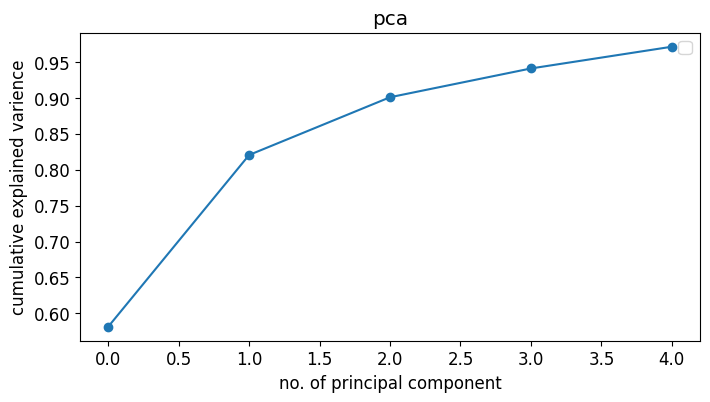

In [42]:
from sklearn.decomposition import PCA

x= data.drop(columns=["target_class"])

scaler = MinMaxScaler()

scaled_data= scaler.fit_transform(x)
explained_variance_ratio=0.95
pca=PCA(n_components=explained_variance_ratio, random_state=42)

pca_features=pca.fit_transform(scaled_data)

print(f'original feature count:{scaled_data.shape[1]}')
print(f'pca feature count for 95% of varience:{pca_features.shape[1]}')

plt.figure(figsize=(8,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('no. of principal component')
plt.ylabel('cumulative explained varience')
plt.title("pca")
plt.legend()
plt.show()

task (d): Kmeans clustering

C:\Users\User\AppData\Local\Temp\ipykernel_208\1077351552.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


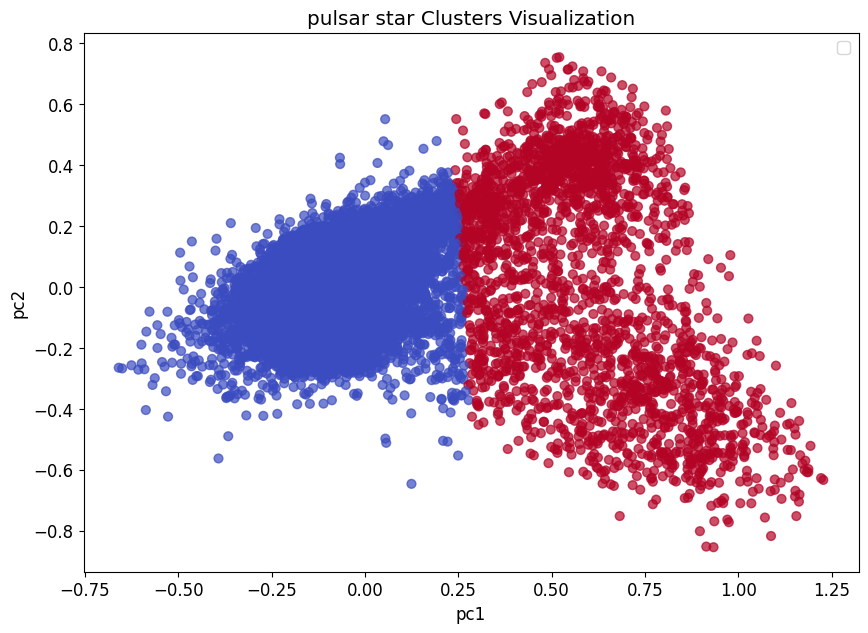

In [61]:

scaler = MinMaxScaler()

kmeans=KMeans(n_clusters=2, n_init='auto', random_state=42)
labels=kmeans.fit_predict(pca_features)
component_names=[f'pc_{i+1}' for i in range(pca_features.shape[1])]
pca_df=pd.DataFrame(pca_features, columns=component_names)
pca_df['cluster']=labels
pca_df.head()

plt.figure(figsize=(10,7))
scatter=plt.scatter(pca_features[:,0],pca_features[:,1],c=labels, cmap='coolwarm', alpha=0.7, s=40)

plt.xlabel('pc1')
plt.ylabel('pc2')
plt.title('pulsar star Clusters Visualization')

plt.legend()
plt.show()

task(e): visualization


Accuracy Of SVM For The Given Dataset :  0.9754189944134078

Confusion Matrix:
[[3239   13]
 [  75  253]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3252
           1       0.95      0.77      0.85       328

    accuracy                           0.98      3580
   macro avg       0.96      0.88      0.92      3580
weighted avg       0.97      0.98      0.97      3580



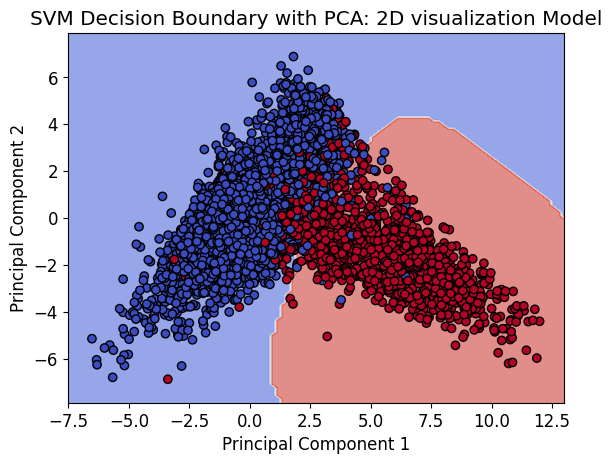

In [ ]:

data = data.dropna()

training_set, test_set = train_test_split(
    data,
    test_size=0.2,
    random_state=1,
    stratify=data["target_class"]
)

X_train = training_set.drop(columns=["target_class"]).values
Y_train = training_set["target_class"].values

X_test = test_set.drop(columns=["target_class"]).values
Y_test = test_set["target_class"].values


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

pca=PCA(n_components=2)
X_train=pca.fit_transform(X_train)
X_test=pca.transform(X_test)


classifier = SVC(
    kernel="rbf",
    C=1,
    gamma='scale',
    random_state=1
)

classifier.fit(X_train, Y_train)

Y_pred = classifier.predict(X_test)

test_set["Predictions"] = Y_pred


cm = confusion_matrix(Y_test, Y_pred)

accuracy = float(cm.diagonal().sum()) / len(Y_test)

print("\nAccuracy Of SVM For The Given Dataset : ", accuracy)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred))



DecisionBoundaryDisplay.from_estimator(
    classifier,
    X_train,
    response_method="predict",
    alpha=0.6,
    cmap=plt.cm.coolwarm
)

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=Y_train,
    edgecolors="k",
    cmap=plt.cm.coolwarm
)

plt.title("SVM Decision Boundary with PCA: 2D visualization Model")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()